# Customer Insights & Recommendation Project
**ReadyNest – Week 2 Task** | Data Analytics

---
### Sections
1. Load & Inspect Raw Data
2. Data Cleaning
3. Merge into Master Dataset
4. Customer Overview
5. Sales Performance
6. Product Performance
7. Customer Segmentation (RFM)
8. Export Cleaned Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

DATA_DIR = '../data/'
ANALYSIS_DATE = pd.Timestamp('2025-06-30')

## 1. Load & Inspect Raw Data

In [2]:
customers = pd.read_csv(DATA_DIR + 'raw_customers.csv', parse_dates=['join_date'])
products  = pd.read_csv(DATA_DIR + 'raw_products.csv')
orders    = pd.read_csv(DATA_DIR + 'raw_orders.csv',   parse_dates=['order_date'])
sales     = pd.read_csv(DATA_DIR + 'raw_sales.csv')

for name, df in [('Customers', customers), ('Products', products),
                 ('Orders', orders), ('Sales', sales)]:
    print(f'--- {name} ---')
    print(f'Shape: {df.shape}')
    print(df.isnull().sum())
    print()

--- Customers ---
Shape: (500, 6)
customer_id       0
name              0
email            23
region            0
join_date         0
customer_type     0
dtype: int64

--- Products ---
Shape: (20, 4)
product_id      0
product_name    0
category        0
unit_price      0
dtype: int64

--- Orders ---
Shape: (1030, 4)
order_id       0
customer_id    0
order_date     0
region         0
dtype: int64

--- Sales ---
Shape: (3000, 6)
sale_id         0
order_id        0
product_id      0
quantity        0
discount        0
total_amount    0
dtype: int64



## 2. Data Cleaning

In [3]:
# ── Customers ──────────────────────────────────────────────────────────────
print('Missing emails before:', customers['email'].isna().sum())
customers['email'] = customers['email'].fillna('unknown@placeholder.com')
customers['region'] = customers['region'].str.strip().str.title()
customers['customer_type'] = customers['customer_type'].str.strip().str.title()
print('Duplicate customer rows:', customers.duplicated('customer_id').sum())
customers = customers.drop_duplicates('customer_id')

# ── Orders ─────────────────────────────────────────────────────────────────
before = len(orders)
orders = orders.drop_duplicates()
print(f'Orders: removed {before - len(orders)} duplicate rows, {len(orders)} remain')

# ── Sales – cap outliers using IQR ─────────────────────────────────────────
Q1, Q3 = sales['total_amount'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_cap = Q3 + 3 * IQR
outliers  = (sales['total_amount'] > upper_cap).sum()
sales['total_amount'] = sales['total_amount'].clip(upper=upper_cap)
print(f'Sales: capped {outliers} outlier values at {upper_cap:.2f}')

Missing emails before: 23
Duplicate customer rows: 0
Orders: removed 30 duplicate rows, 1000 remain
Sales: capped 135 outlier values at 491.78


## 3. Merge into Master Dataset

In [4]:
master = (
    sales
    .merge(orders[['order_id','customer_id','order_date','region']], on='order_id', how='left')
    .merge(customers[['customer_id','name','email','join_date','customer_type']], on='customer_id', how='left')
    .merge(products, on='product_id', how='left')
)
master['year_month'] = master['order_date'].dt.to_period('M')
print('Master shape:', master.shape)
master.head(3)

Master shape: (3000, 17)


,sale_id,order_id,product_id,quantity,discount,total_amount,customer_id,order_date,region,name,email,join_date,customer_type,product_name,category,unit_price,year_month
0,S000001,O00562,P016,2,0.00,79.98,C0019,2023-08-11,Central,Priya Martinez,layla.okonkwo43@outlook.com,2025-01-14,New,Python Programming,Books,39.99,2023-08
1,S000002,O00689,P016,2,0.15,67.98,C0198,2024-11-30,West,Liam Williams,ethan.lee49@hotmail.com,2023-03-21,Returning,Python Programming,Books,39.99,2024-11
2,S000003,O00947,P006,2,0.20,127.98,C0021,2023-04-28,South,Arjun Singh,aisha.sharma95@gmail.com,2024-10-22,New,Running Shoes,Footwear,79.99,2023-04


## 4. Customer Overview

Total Customers : 500
New             : 239 (47.8%)
Returning       : 261 (52.2%)


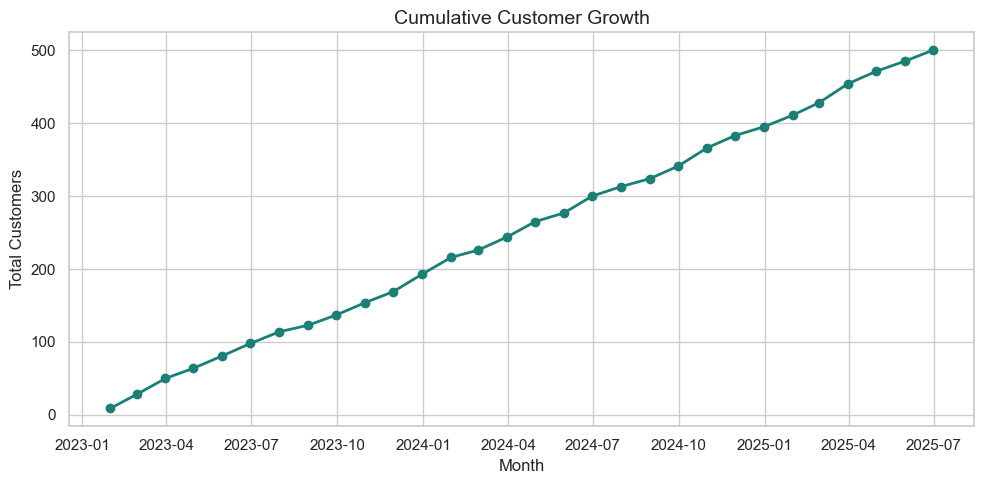

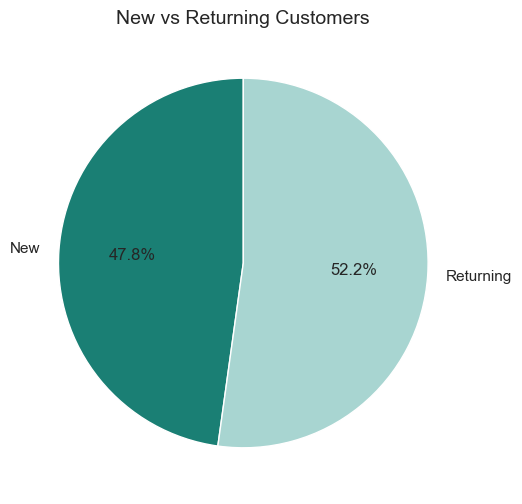

In [5]:
total_customers = customers['customer_id'].nunique()
new_customers   = (customers['customer_type'] == 'New').sum()
returning       = (customers['customer_type'] == 'Returning').sum()

print(f'Total Customers : {total_customers}')
print(f'New             : {new_customers} ({new_customers/total_customers*100:.1f}%)')
print(f'Returning       : {returning} ({returning/total_customers*100:.1f}%)')

# Customer growth by month
growth = customers.set_index('join_date').resample('M')['customer_id'].count().cumsum()
fig, ax = plt.subplots()
ax.plot(growth.index, growth.values, marker='o', color='#1a7f74', linewidth=2)
ax.set_title('Cumulative Customer Growth')
ax.set_xlabel('Month'); ax.set_ylabel('Total Customers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout(); plt.show()

# New vs Returning pie
fig, ax = plt.subplots(figsize=(6,6))
ax.pie([new_customers, returning], labels=['New','Returning'],
       autopct='%1.1f%%', colors=['#1a7f74','#a8d5d1'], startangle=90)
ax.set_title('New vs Returning Customers')
plt.show()

## 5. Sales Performance

Total Sales   : $389,230.13


Total Orders  : 939
Avg Order Val : $414.52


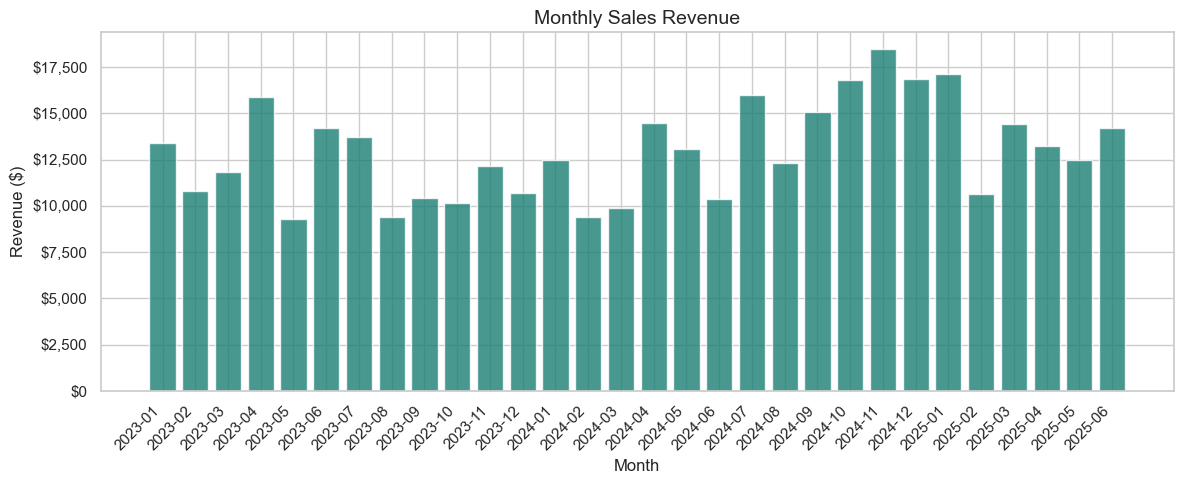

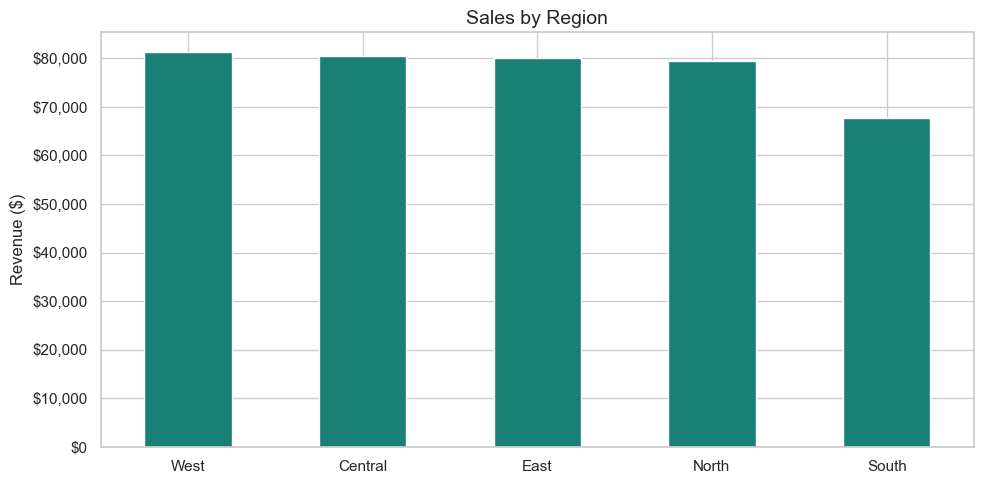

In [6]:
total_sales  = master['total_amount'].sum()
total_orders = master['order_id'].nunique()
avg_order    = master.groupby('order_id')['total_amount'].sum().mean()

print(f'Total Sales   : ${total_sales:,.2f}')
print(f'Total Orders  : {total_orders:,}')
print(f'Avg Order Val : ${avg_order:,.2f}')

# Monthly sales trend
monthly = master.groupby('year_month')['total_amount'].sum().reset_index()
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(12,5))
ax.bar(monthly['year_month_str'], monthly['total_amount'], color='#1a7f74', alpha=0.8)
ax.set_title('Monthly Sales Revenue')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

# Sales by region
region_sales = master.groupby('region')['total_amount'].sum().sort_values(ascending=False)
fig, ax = plt.subplots()
region_sales.plot(kind='bar', ax=ax, color='#1a7f74', edgecolor='white')
ax.set_title('Sales by Region')
ax.set_xlabel(''); ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 6. Product Performance

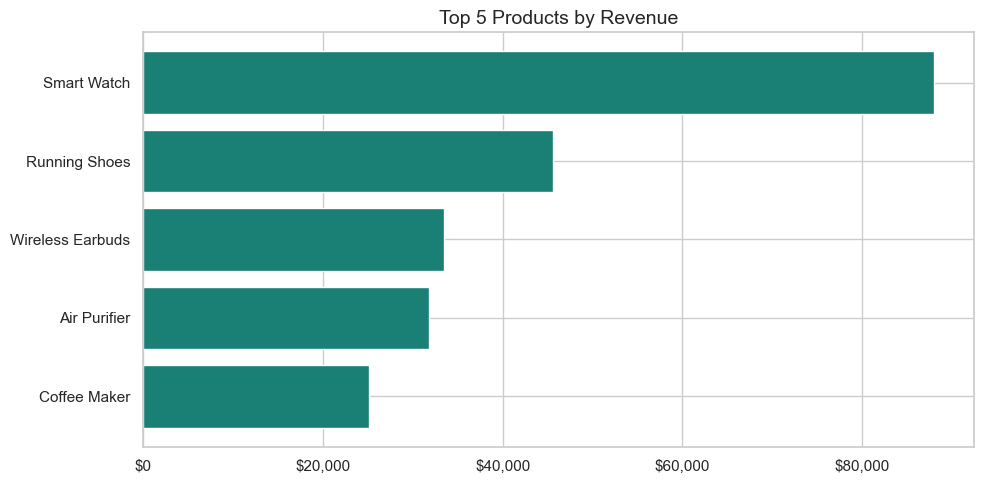

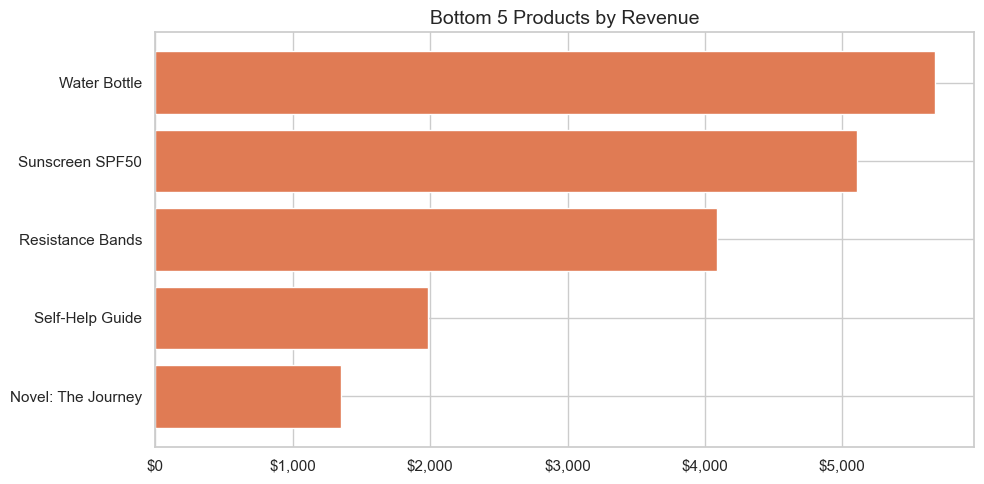

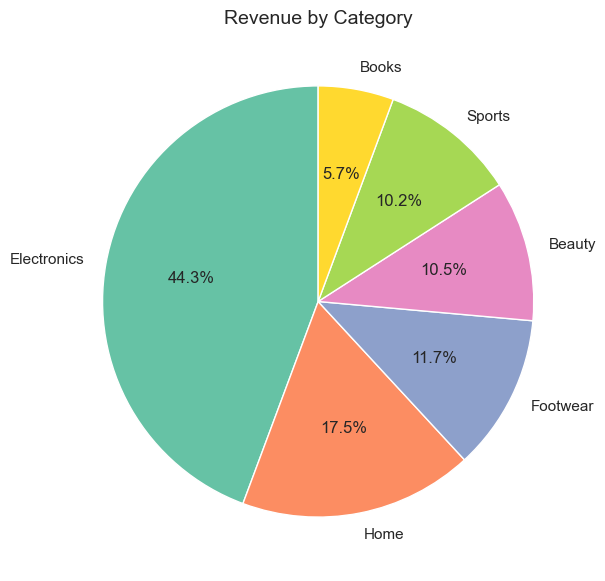

In [7]:
prod_perf = (
    master.groupby(['product_id','product_name','category'])
    .agg(total_revenue=('total_amount','sum'), units_sold=('quantity','sum'))
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

# Top 5
top5 = prod_perf.head(5)
fig, ax = plt.subplots()
ax.barh(top5['product_name'], top5['total_revenue'], color='#1a7f74')
ax.invert_yaxis()
ax.set_title('Top 5 Products by Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout(); plt.show()

# Bottom 5
bot5 = prod_perf.tail(5)
fig, ax = plt.subplots()
ax.barh(bot5['product_name'], bot5['total_revenue'], color='#e07b54')
ax.invert_yaxis()
ax.set_title('Bottom 5 Products by Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout(); plt.show()

# Category breakdown
cat_perf = master.groupby('category')['total_amount'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,7))
ax.pie(cat_perf.values, labels=cat_perf.index, autopct='%1.1f%%',
       colors=sns.color_palette('Set2', len(cat_perf)), startangle=90)
ax.set_title('Revenue by Category')
plt.show()

## 7. Customer Segmentation (RFM Analysis)

segment
Medium Value    218
High Value       85
Low Value        64
Name: count, dtype: int64


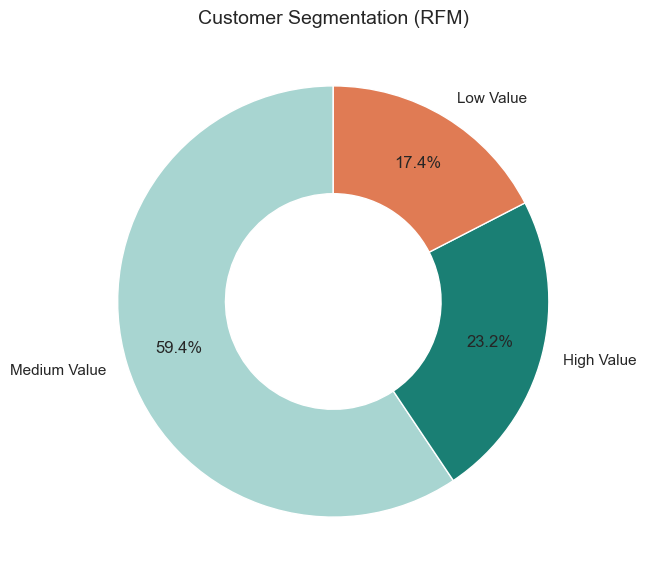

              customers  avg_spend  avg_frequency
segment                                          
High Value           85    2327.92           5.28
Low Value            64     270.75           1.14
Medium Value        218     798.30           1.91


In [8]:
# Aggregate per customer
cust_orders = master.groupby('customer_id').agg(
    last_order_date = ('order_date','max'),
    frequency       = ('order_id', pd.Series.nunique),
    monetary        = ('total_amount','sum')
).reset_index()

cust_orders['recency'] = (ANALYSIS_DATE - cust_orders['last_order_date']).dt.days

# Score each dimension 1-3 using quantile cuts
def rfm_score(series, reverse=False):
    labels = [3, 2, 1] if reverse else [1, 2, 3]
    try:
        return pd.qcut(series, q=3, labels=labels, duplicates='drop')
    except Exception:
        return pd.cut(series, bins=3, labels=labels)

cust_orders['R_score'] = rfm_score(cust_orders['recency'],  reverse=True).astype(int)
cust_orders['F_score'] = rfm_score(cust_orders['frequency']).astype(int)
cust_orders['M_score'] = rfm_score(cust_orders['monetary']).astype(int)
cust_orders['RFM_total'] = cust_orders['R_score'] + cust_orders['F_score'] + cust_orders['M_score']

def segment(score):
    if score >= 7: return 'High Value'
    elif score >= 4: return 'Medium Value'
    else: return 'Low Value'

cust_orders['segment'] = cust_orders['RFM_total'].apply(segment)

seg_counts = cust_orders['segment'].value_counts()
print(seg_counts)

# Donut chart
colors = {'High Value':'#1a7f74','Medium Value':'#a8d5d1','Low Value':'#e07b54'}
fig, ax = plt.subplots(figsize=(7,7))
wedge_colors = [colors[s] for s in seg_counts.index]
wedges, texts, autotexts = ax.pie(
    seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
    colors=wedge_colors, startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5))
ax.set_title('Customer Segmentation (RFM)')
plt.show()

# Segment revenue summary
seg_summary = cust_orders.groupby('segment').agg(
    customers=('customer_id','count'),
    avg_spend=('monetary','mean'),
    avg_frequency=('frequency','mean')
).round(2)
print(seg_summary)

## 8. Top Customers

In [9]:
top_customers = (
    cust_orders
    .merge(customers[['customer_id','name','region','customer_type']], on='customer_id')
    .sort_values('monetary', ascending=False)
    .head(10)[['customer_id','name','region','customer_type','frequency','monetary','segment']]
)
top_customers['monetary'] = top_customers['monetary'].round(2)
print('Top 10 Customers by Spend:')
top_customers

Top 10 Customers by Spend:


,customer_id,name,region,customer_type,frequency,monetary,segment
307,C0422,Vikram Williams,Central,Returning,12,5954.74,High Value
186,C0269,Liam Williams,North,Returning,10,5121.01,High Value
124,C0185,Zara Khan,East,Returning,11,4897.98,High Value
198,C0283,Liam Nkosi,West,New,8,4206.67,High Value
110,C0163,James Patel,West,Returning,6,4058.67,High Value
23,C0033,Mei Gupta,Central,Returning,8,3854.14,High Value
13,C0021,Arjun Singh,South,New,5,3660.13,High Value
166,C0243,Emma Lee,North,Returning,7,3500.57,High Value
248,C0347,Omar Lopez,North,Returning,4,3494.79,High Value
128,C0191,Ethan Johnson,Central,Returning,6,3484.63,High Value


## 9. Export Cleaned Dataset

In [10]:
cleaned = master.merge(
    cust_orders[['customer_id','recency','frequency','monetary','RFM_total','segment']],
    on='customer_id', how='left'
)

cleaned.to_csv(DATA_DIR + 'cleaned_customer_insights.csv', index=False)
print(f'Exported cleaned_customer_insights.csv — {len(cleaned):,} rows, {len(cleaned.columns)} columns')
print('Columns:', list(cleaned.columns))
print('Null counts:')
print(cleaned.isnull().sum()[cleaned.isnull().sum() > 0])

Exported cleaned_customer_insights.csv — 3,000 rows, 22 columns
Columns: ['sale_id', 'order_id', 'product_id', 'quantity', 'discount', 'total_amount', 'customer_id', 'order_date', 'region', 'name', 'email', 'join_date', 'customer_type', 'product_name', 'category', 'unit_price', 'year_month', 'recency', 'frequency', 'monetary', 'RFM_total', 'segment']
Null counts:
Series([], dtype: int64)
